# DDoSimu5G — 5G KPI Analysis

Plots 1–4: UPF Incoming Data Rate per scenario.  
Plot 5: UE RLC UL Packet Loss (UE ID ≥ 100) — TC002 vs TC003.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path
from matplotlib.ticker import FuncFormatter

DATA_DIR = Path("../../simulations/CaseID/Test-cases-001a/run_results/extracted_data")
print("Data dir exists:", DATA_DIR.exists())

Data dir exists: True


In [7]:
def load_upf(label, scale=1e3):
    """Load UPF incoming data rate. scale=1e3 → kbit/s, 1e6 → Mbit/s."""
    path = DATA_DIR / f"{label}_upf_incomingDataRate.csv"
    if not path.exists():
        print(f"⚠ {path.name} not found")
        return None, None
    df = pd.read_csv(path)
    row = df[df["type"] == "vector"].iloc[0]
    t = np.fromstring(row["vectime"], sep=" ")
    v = np.fromstring(row["vecvalue"], sep=" ") / scale
    return t, v

def plot_upf(label, title, unit="kbit/s", scale=1e3):
    t, v = load_upf(label, scale=scale)
    if t is None:
        print(f"No data for {label}")
        return
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t, v, color="blue", linewidth=0.6, label=f"UPF IncomingDataRate ({unit})")
    ax.set_xlabel("Simulation Time (s)")
    ax.set_ylabel("Data Rate")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f} {unit}"))
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

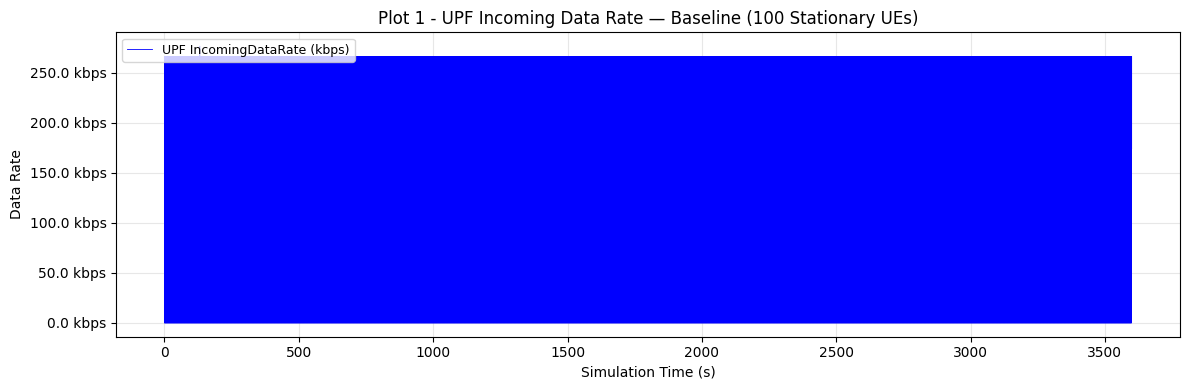

In [8]:
# Plot 1 – Baseline
plot_upf("Baseline-TC", "Plot 1 - UPF Incoming Data Rate — Baseline (100 Stationary UEs)",unit="kbps", scale=1e3)

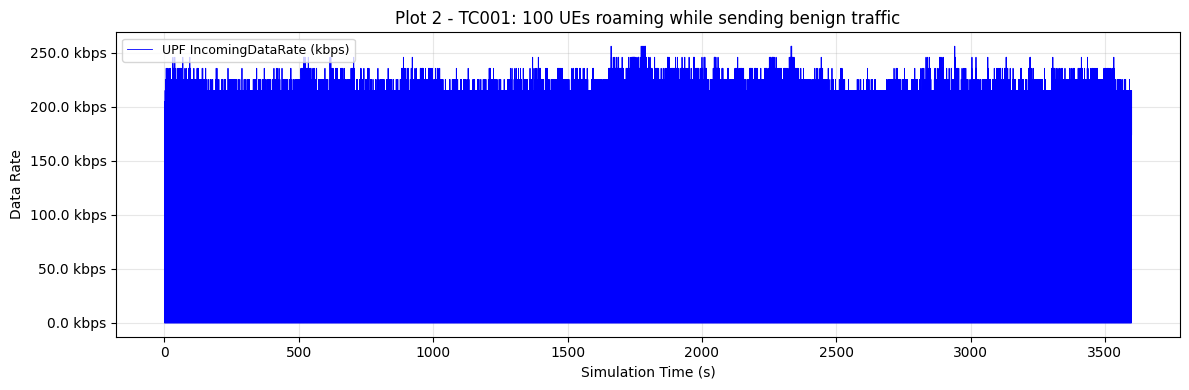

In [9]:
# Plot 2 – TC001
plot_upf("TC001", "Plot 2 - TC001: 100 UEs roaming while sending benign traffic",unit="kbps", scale=1e3)

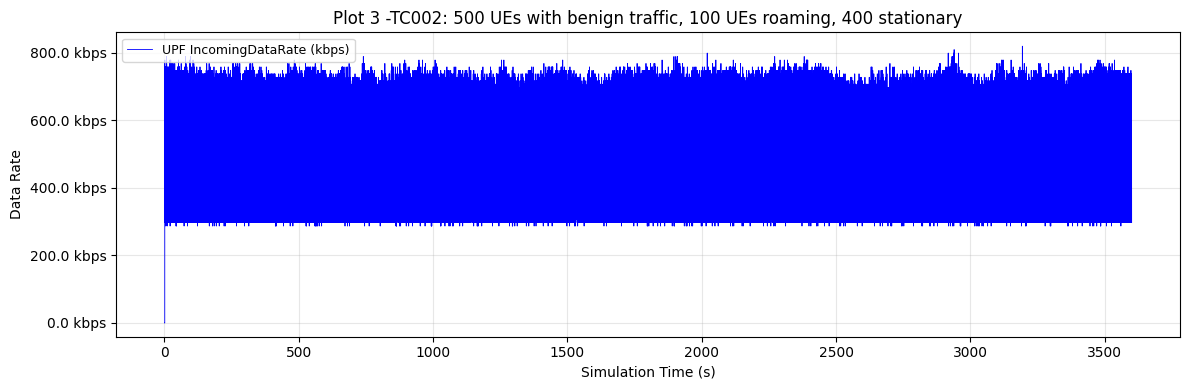

In [10]:
# Plot 3 – TC002
plot_upf("TC002", "Plot 3 -TC002: 500 UEs with benign traffic, 100 UEs roaming, 400 stationary",unit="kbps", scale=1e3)

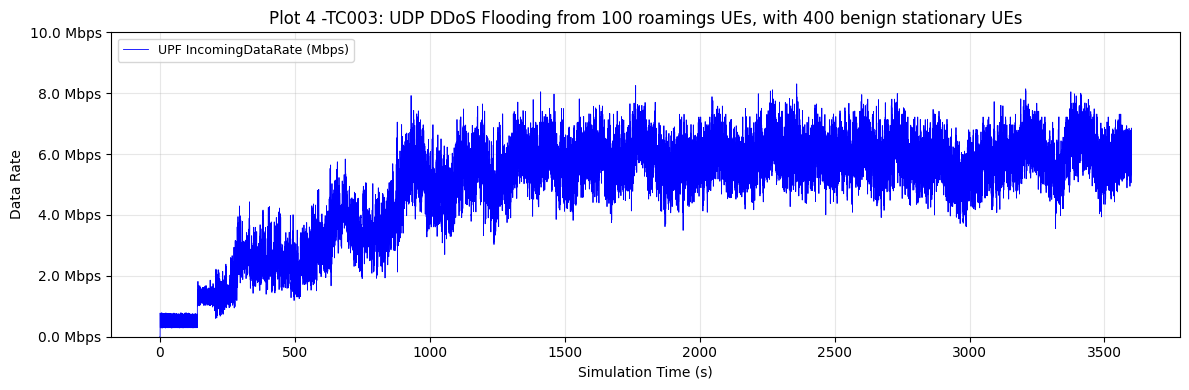

In [13]:
# Plot 4 – TC003
plot_upf("TC003", "Plot 4 -TC003: UDP DDoS Flooding from 100 roamings UEs, with 400 benign stationary UEs",unit="Mbps", scale=1e6)